In [1]:
!pip install seaborn


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: C:\Users\PC\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
!pip install matplotlib


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: C:\Users\PC\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
!pip install openpyxl


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: C:\Users\PC\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [4]:
pip freeze > requirements.txt

Note: you may need to restart the kernel to use updated packages.


### **Khai báo thư viện và thiết lập giao diện**

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Thiết lập font và style vẽ biểu đồ chuyên nghiệp
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

In [6]:
# Đường dẫn lùi lại một thư mục (..) để vào thư mục data
df = pd.read_excel('../data/raw/labeled_comments.xlsx')

if 'goi_y_cua_may' in df.columns:
    df = df.drop(columns=['goi_y_cua_may'])

# Lọc các dòng hợp lệ
df = df.dropna(subset=['Text', 'label'])
df['label'] = df['label'].str.lower().str.strip()
df = df[df['label'].isin(['positive', 'negative'])]

print(f"Tổng số bình luận đánh nhãn: {len(df)} dòng")
display(df.head(10))

Tổng số bình luận đánh nhãn: 1242 dòng


,ID,Text,label
0,32082,củ nghệ,positive
1,27591,"Mình thích lắm nha, dây màu đẹp, chuẩn lắm, kh...",positive
2,34316,tai nghe gia công tốt giá hợp lý còn độ bền ph...,positive
3,746,Sản phẩm gia công đẹp. Thiết kế mở nắp không t...,positive
4,24201,Mở ra thì sản phẩm đã bị bóc rồi. 1 bên hơi ch...,negative
5,13005,Always never strike lucky draw,negative
6,41952,"Mua được 3tháng, chơi game không mượt bằng Xia...",positive
7,2580,chất_liệu chất_liệu ok,positive
8,16360,"Đã nhận hàng, sản phẩm đóng gói còn nguyên hộp.",positive
9,4581,đúng với mô_tả chuẩn,positive


### **Biểu đồ phân bố nhãn**

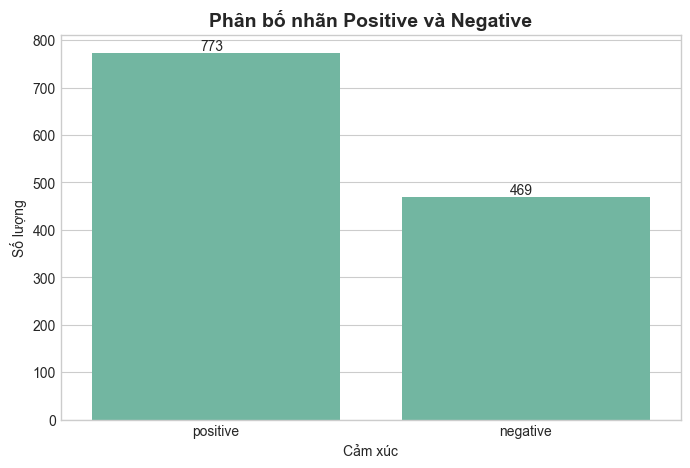

In [7]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='label', order=['positive', 'negative'])
plt.title('Phân bố nhãn Positive và Negative', fontsize=14, fontweight='bold')
plt.xlabel('Cảm xúc')
plt.ylabel('Số lượng')

# Gắn số lượng trực tiếp lên đỉnh các cột
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + 0.35, p.get_height() + 5))
plt.show()

### **Biểu đồ độ dài văn bản**

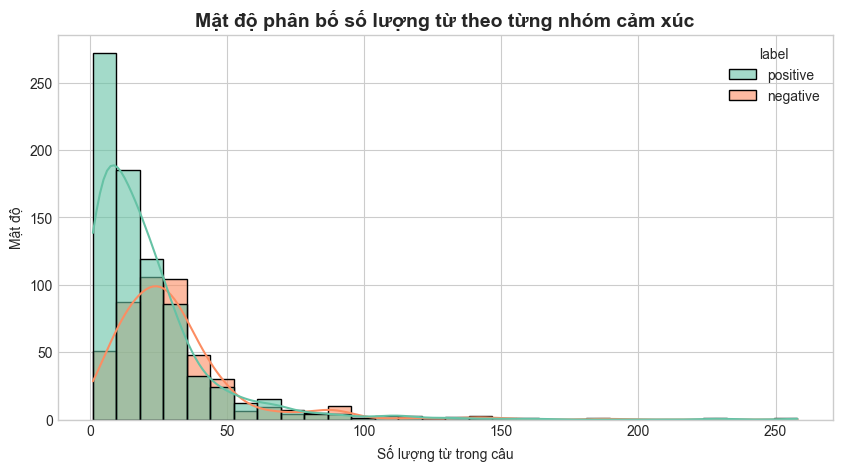

In [8]:
# Đếm số lượng từ trong mỗi bình luận
df['word_count'] = df['Text'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='word_count', hue='label', kde=True, bins=30, alpha=0.6)
plt.title('Mật độ phân bố số lượng từ theo từng nhóm cảm xúc', fontsize=14, fontweight='bold')
plt.xlabel('Số lượng từ trong câu')
plt.ylabel('Mật độ')
plt.show()